*Simulation for Decision Making (S4DM)*

# Motivation & Course Organization

Gunther Gust & Govind Rao <br>
Chair for Enterprise AI <br>
Data Driven Decisions Group <br>
Center for Artificial Intelligence and Data Science (CAIDAS)

<img src="images/d3.png" style="width:20%; float:left;" />

<img src="images/CAIDASlogo.png" style="width:20%; float:left;" />

## Getting Started: Access & Run the Notebooks

Follow these steps to set up your environment for the course:

**1. Create a GitHub account** (if you don't have one)
- Go to [github.com](https://github.com) and sign up with your university email address.

**2. Access the lecture notebooks**
- The lecture notebooks are available in our shared repository on GitHub.
- You will find the link on **WueCampus**.

**3. Open a Codespace**
- In the repository, click the green **"Code"** button → select the **"Codespaces"** tab → click **"Create codespace on main"**.
- This opens a fully configured VS Code editor in your browser — no local installation needed.

**4. Run a notebook**
- In the file explorer (left panel), click on the notebook you want to open.
- To run a cell, click the ▶ button next to it or press **Shift + Enter**.
- When prompted to select a kernel, choose <span style="color:red; font-weight:bold;">Python 3.12</span> (not 3.11!).

**5. Exercises (via GitHub Classroom)**
- For each exercise, you will receive a separate **invitation link** on WueCampus.
- Click the link and accept the assignment — this creates a personal copy of the exercise for you.
- Open it in a Codespace the same way as above.

> **Tip:** Codespaces are free for up to 60 hours/month on the GitHub Free plan. Remember to stop your Codespace when you're done (click your profile picture → "Your codespaces" → "Stop").

# Motivating Question

The university administration wants to improve the service quality in the cafeteria (Mensa am Sanderring) and tasks you with finding measures to reduce student waiting times. Specifically, the university administration wants to know:

> **By how much would an additional cashier reduce the average waiting time during peak hours?**

Take 2 minutes and think about: **Which approaches do you know to answer this question?**

1. Could you **calculate** the answer with a formula? What would you need to know?
2. Could you **test it in practice** — e.g., open a 4th checkout for a week? What are the risks?
3. Is there another way to **experiment** without changing the real system?

Submit your ideas via **Mentimeter**.

By the end of this lecture, you will have a robust, data-driven answer — and a method that scales to much more complex scenarios.

# Modeling the Cafeteria

We answer the question with a **simulation model**. A model is a simplified representation of the real system "cafeteria". First, we determine which components need to be included in the model.

The sequence of a cafeteria visit:

| Step | Component |
|---------|------------|
| a | Traffic light at the intersection |
| b | Cafeteria door (entrance) |
| c | Food counter |
| d | Cashier area (waiting) |
| e | Payment process |
| f | Eating |
| g | Dish return |
| h | Cafeteria door (exit) |

**Modeling decision:** Which components do we need to include in the model? Answer via __Mentimeter__.

# Data Collection

Imagine you have observed the cafeteria during peak hours and estimated the following:
- Arrival rate: 3 students/minute (≈ 180/hour)
- Service time at checkout: 0.9 minutes (≈ 54 seconds)
- Number of checkouts: 3
- Utilization: ρ = 0.9 / (3 × ⅓) = **0.9 (90%)**

# Step 1: Deterministic Model

First, we let arrivals and service run **deterministically**:
- Students arrive **exactly** every ⅓ minute (= 20 seconds).
- The service time is **exactly** 0.9 minutes.
- There are **3 checkouts**.

> **Question:** Does a queue form under these conditions? --> Answer on __Mentimeter__.


In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────────
NUM_REGISTERS      = 3      # Number of checkouts
SERVICE_TIME       = 0.9    # Service time in minutes (deterministic)
INTER_ARRIVAL_TIME = 1 / 3  # Inter-arrival time in minutes (= 20 sec, 180/hour)
SIM_TIME           = 60     # Simulation duration in minutes (peak hour)

In [2]:
class CashRegister:
    """A checkout with limited capacity (number of parallel service processes)."""

    def __init__(self, env, num_registers, service_time):
        self.env = env
        self.resource = simpy.Resource(env, capacity=num_registers)
        self.service_time = service_time

    def serve(self, student_name):
        """Service process — takes service_time minutes."""
        yield self.env.timeout(self.service_time)

In [3]:
class Student:
    """A student visiting the cafeteria."""

    def __init__(self, env, name, results):
        self.env = env
        self.name = name
        self.results = results

    def run(self, cash_register):
        """Process: arrive → possibly wait → pay → leave."""
        arrival_time = self.env.now
        queue_length = len(cash_register.resource.queue)

        self.results['queue_at_arrival'].append((arrival_time, queue_length))

        with cash_register.resource.request() as req:
            yield req  # wait until a checkout is free

            wait_time = self.env.now - arrival_time
            self.results['waiting_times'].append(wait_time)

            yield self.env.process(cash_register.serve(self.name))

In [4]:
def student_generator(env, inter_arrival_time, cash_register, results):
    """Continuously generates students at intervals of inter_arrival_time."""
    student_id = 0
    while True:
        yield env.timeout(inter_arrival_time)
        student = Student(env, f'Student {student_id}', results)
        student_id += 1
        env.process(student.run(cash_register))

In [5]:
# ── Run simulation ─────────────────────────────────────────────────────────────────
results = {'waiting_times': [], 'queue_at_arrival': []}

env           = simpy.Environment()
cash_register = CashRegister(env, NUM_REGISTERS, SERVICE_TIME)
env.process(student_generator(env, INTER_ARRIVAL_TIME, cash_register, results))
env.run(until=SIM_TIME)

# ── Print results ──────────────────────────────────────────────────────────────────
waiting_times = results['waiting_times']
print(f"Simulated students:      {len(waiting_times)}")
print(f"Mean waiting time:       {np.mean(waiting_times):.2f} min")
print(f"Maximum waiting time:    {np.max(waiting_times):.2f} min")
print(f"Students without wait:   {sum(w == 0 for w in waiting_times)} "
      f"({100 * sum(w == 0 for w in waiting_times) / len(waiting_times):.0f}%)")

Simulated students:      179
Mean waiting time:       0.00 min
Maximum waiting time:    0.00 min
Students without wait:   179 (100%)


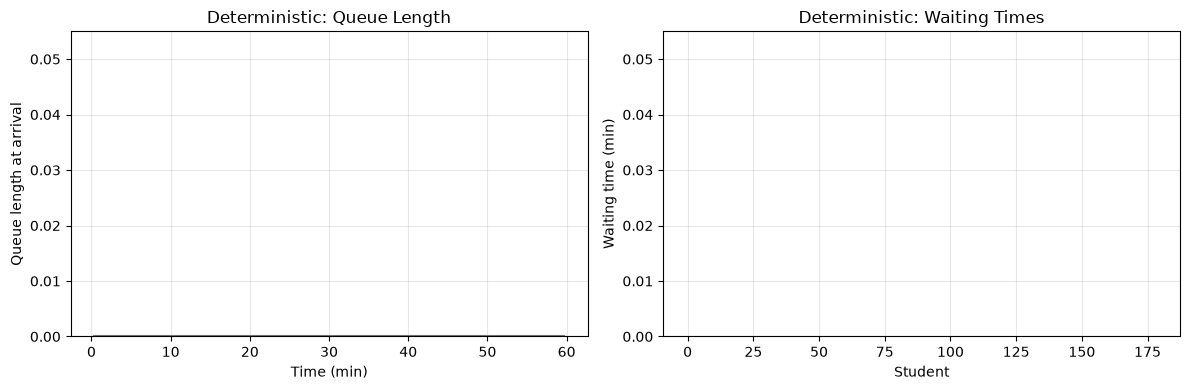

In [6]:
# ── Visualization ───────────────────────────────────────────────────────────────────
times  = [t for t, q in results['queue_at_arrival']]
queues = [q for t, q in results['queue_at_arrival']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].step(times, queues, where='post', color='steelblue')
axes[0].set_xlabel('Time (min)')
axes[0].set_ylabel('Queue length at arrival')
axes[0].set_title('Deterministic: Queue Length')
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(len(waiting_times)), waiting_times, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Student')
axes[1].set_ylabel('Waiting time (min)')
axes[1].set_title('Deterministic: Waiting Times')
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Answer

**No** – no queue forms.

The total capacity of the 3 checkouts (3 / 0.9 ≈ 3.33 students/min) exceeds the arrival rate (3 students/min). Every student deterministically finds a free checkout. The system is **90% utilized** — but deterministically there is no waiting.

> But is this realistic? In reality, students do not arrive at exact intervals, and payment processes sometimes take shorter or longer.
>
> → **Step 2:** What happens when we account for this randomness?

# Step 2: Stochastic Model

In reality, students do not arrive at exact intervals — and payment processes sometimes take shorter or longer. We replace the fixed times with **random variables**:

| | Step 1 (deterministic) | Step 2 (stochastic) |
|---|---|---|
| Inter-arrival time | exactly ⅓ min | Exp-distributed, mean ⅓ min |
| Service time | exactly 0.9 min | Exp-distributed, mean 0.9 min |
| Utilization ρ | 0.9 | 0.9 |

The **means are identical** — only the randomness changes.

> **Question:** Does a queue form now? --> Vote on __Mentimeter.__ 

In [7]:
import random

# ── Parameters (same means as in Step 1) ───────────────────────────────────────
NUM_REGISTERS       = 3      # Number of checkouts
MEAN_SERVICE_TIME   = 0.9    # Mean service time in minutes
MEAN_INTER_ARRIVAL  = 1 / 3  # Mean inter-arrival time in minutes
SIM_TIME            = 60     # Simulation duration in minutes
RANDOM_SEED         = 42

We change exactly **two places** in the code compared to Step 1:
1.  → draws a random service time instead of a fixed value
2.  → draws a random inter-arrival time instead of a fixed value

The  class remains unchanged.

In [8]:
class StochasticCashRegister:
    """Checkout with random service time (exponential distribution)."""

    def __init__(self, env, num_registers, mean_service_time):
        self.env = env
        self.resource = simpy.Resource(env, capacity=num_registers)
        self.mean_service_time = mean_service_time

    def serve(self, student_name):
        service_time = random.expovariate(1 / self.mean_service_time)  # ← new
        yield self.env.timeout(service_time)


def stochastic_student_generator(env, mean_inter_arrival, cash_register, results):
    """Generates students with random inter-arrival times (exponential distribution)."""
    student_id = 0
    while True:
        yield env.timeout(random.expovariate(1 / mean_inter_arrival))  # ← new
        student = Student(env, f'Student {student_id}', results)
        student_id += 1
        env.process(student.run(cash_register))

In [9]:
# ── Run simulation ─────────────────────────────────────────────────────────────────
random.seed(RANDOM_SEED)
results_stoch = {'waiting_times': [], 'queue_at_arrival': []}

env           = simpy.Environment()
cash_register = StochasticCashRegister(env, NUM_REGISTERS, MEAN_SERVICE_TIME)
env.process(stochastic_student_generator(env, MEAN_INTER_ARRIVAL, cash_register, results_stoch))
env.run(until=SIM_TIME)

# ── Print results ──────────────────────────────────────────────────────────────────
wt = results_stoch['waiting_times']
print(f"Simulated students:      {len(wt)}")
print(f"Mean waiting time:       {np.mean(wt):.2f} min")
print(f"Maximum waiting time:    {np.max(wt):.2f} min")
print(f"Students without wait:   {sum(w == 0 for w in wt)} ({100 * sum(w == 0 for w in wt) / len(wt):.0f}%)")

Simulated students:      165
Mean waiting time:       0.83 min
Maximum waiting time:    3.80 min
Students without wait:   48 (29%)


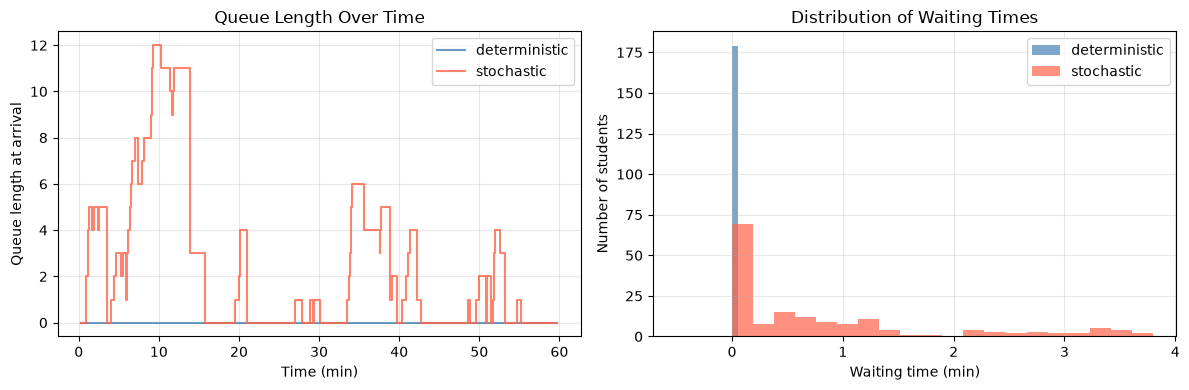

In [10]:
# ── Visualization: Comparison deterministic vs. stochastic ───────────────
times_s  = [t for t, q in results_stoch['queue_at_arrival']]
queues_s = [q for t, q in results_stoch['queue_at_arrival']]

times_d  = [t for t, q in results['queue_at_arrival']]
queues_d = [q for t, q in results['queue_at_arrival']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Queue length over time
axes[0].step(times_d, queues_d, where='post', color='steelblue', label='deterministic', alpha=0.8)
axes[0].step(times_s, queues_s, where='post', color='tomato',    label='stochastic',   alpha=0.8)
axes[0].set_xlabel('Time (min)')
axes[0].set_ylabel('Queue length at arrival')
axes[0].set_title('Queue Length Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of waiting times
axes[1].hist(results['waiting_times'],       bins=20, color='steelblue', alpha=0.7, label='deterministic')
axes[1].hist(results_stoch['waiting_times'], bins=20, color='tomato',    alpha=0.7, label='stochastic')
axes[1].set_xlabel('Waiting time (min)')
axes[1].set_ylabel('Number of students')
axes[1].set_title('Distribution of Waiting Times')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Answer

**Yes** – even though the means are identical, a significant queue forms.

This is due to the **variability effect**: When several students happen to arrive in quick succession, or a payment process takes longer than average, a queue builds up — and then only dissipates slowly because the checkout is already highly utilized.

> This phenomenon **cannot** be predicted by simple calculations with averages. It requires simulation.

But: How reliable is the result? If we run the simulation again — with a different random seed — do we get the same result?

→ **Step 3:** Output stochasticity

## Class Experiment

Run the following cell (without a fixed seed) and report your mean waiting time via **Mentimeter**.

In [11]:
# ── No fixed seed → everyone gets a different result ──────────────────────
res_single = {'waiting_times': [], 'queue_at_arrival': []}
env = simpy.Environment()
cr  = StochasticCashRegister(env, NUM_REGISTERS, MEAN_SERVICE_TIME)
env.process(stochastic_student_generator(env, MEAN_INTER_ARRIVAL, cr, res_single))
env.run(until=SIM_TIME)

print(f"My mean waiting time: {np.mean(res_single['waiting_times']):.2f} min")

My mean waiting time: 1.83 min


# Step 3: Output Stochasticity

Our result so far is based on **a single simulation run** with a fixed seed. But is that reliable?

We repeat the simulation with 10 different seeds and see what happens.

In [12]:
def run_simulation(seed):
    """Runs a single simulation and returns the mean waiting time."""
    random.seed(seed)
    res = {'waiting_times': [], 'queue_at_arrival': []}
    env = simpy.Environment()
    cr  = StochasticCashRegister(env, NUM_REGISTERS, MEAN_SERVICE_TIME)
    env.process(stochastic_student_generator(env, MEAN_INTER_ARRIVAL, cr, res))
    env.run(until=SIM_TIME)
    return np.mean(res['waiting_times'])


# ── 10 runs with different seeds ─────────────────────────────────────────
seeds        = list(range(10))
single_means = [run_simulation(s) for s in seeds]

for s, m in zip(seeds, single_means):
    print(f"  Seed {s:2d}:  mean waiting time = {m:.2f} min")

  Seed  0:  mean waiting time = 0.36 min
  Seed  1:  mean waiting time = 0.64 min
  Seed  2:  mean waiting time = 0.67 min
  Seed  3:  mean waiting time = 0.52 min
  Seed  4:  mean waiting time = 0.76 min
  Seed  5:  mean waiting time = 0.30 min
  Seed  6:  mean waiting time = 5.05 min
  Seed  7:  mean waiting time = 4.13 min
  Seed  8:  mean waiting time = 0.61 min
  Seed  9:  mean waiting time = 2.18 min


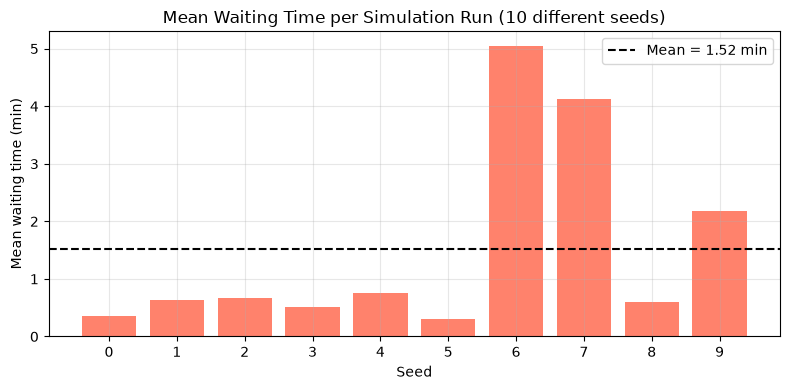

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(seeds, single_means, color='tomato', alpha=0.8)
ax.axhline(np.mean(single_means), color='black', linestyle='--', label=f'Mean = {np.mean(single_means):.2f} min')
ax.set_xlabel('Seed')
ax.set_ylabel('Mean waiting time (min)')
ax.set_title('Mean Waiting Time per Simulation Run (10 different seeds)')
ax.set_xticks(seeds)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Solution: Many Replications + Confidence Interval

The values you reported are themselves a sample — and their mean is already a better estimate than a single run.

Formally, we proceed as follows: We perform **N independent replications**. Each yields a mean waiting time $\bar{x}_i$. From these we compute:

$$\bar{x} = \frac{1}{N} \sum_{i=1}^{N} \bar{x}_i \qquad \text{(point estimator)}$$

$$SE = \frac{s}{\sqrt{N}} \qquad \text{(standard error)}$$

$$CI_{95\%} = \bar{x} \;\pm\; t_{0.975,\, N-1} \cdot SE \qquad \text{(confidence interval)}$$

In [14]:
from scipy import stats

N_REPLICATIONS = 30

replication_means = [run_simulation(seed) for seed in range(N_REPLICATIONS)]

# ── Confidence interval ────────────────────────────────────────────────────────
n      = len(replication_means)
x_bar  = np.mean(replication_means)
se     = np.std(replication_means, ddof=1) / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n - 1)
ci_lo  = x_bar - t_crit * se
ci_hi  = x_bar + t_crit * se

print(f"Replications:            {n}")
print(f"Point estimator x̄:       {x_bar:.2f} min")
print(f"Standard error SE:       {se:.2f} min")
print(f"95% confidence interval: [{ci_lo:.2f}, {ci_hi:.2f}] min")

Replications:            30
Point estimator x̄:       1.27 min
Standard error SE:       0.21 min
95% confidence interval: [0.85, 1.70] min


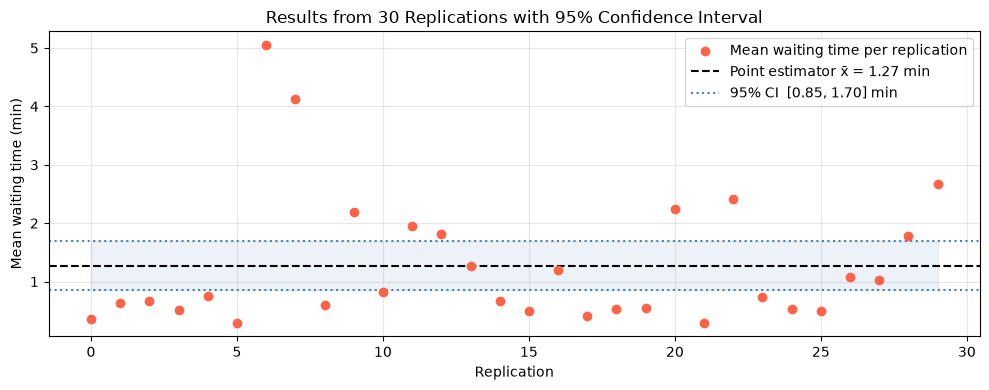

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(range(n), replication_means, color='tomato', zorder=3, label='Mean waiting time per replication')
ax.axhline(x_bar,  color='black',      linestyle='--', linewidth=1.5, label=f'Point estimator x̄ = {x_bar:.2f} min')
ax.axhline(ci_lo,  color='steelblue',  linestyle=':',  linewidth=1.5, label=f'95% CI  [{ci_lo:.2f}, {ci_hi:.2f}] min')
ax.axhline(ci_hi,  color='steelblue',  linestyle=':',  linewidth=1.5)
ax.fill_between(range(n), ci_lo, ci_hi, alpha=0.1, color='steelblue')

ax.set_xlabel('Replication')
ax.set_ylabel('Mean waiting time (min)')
ax.set_title(f'Results from {n} Replications with 95% Confidence Interval')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

With 30 replications, we can reliably estimate the mean waiting time with 3 checkouts during peak hours and provide a 95% confidence interval.

> **Remember:** A single simulation run is like a single coin flip. Only many independent runs yield a reliable statement.

→ **Step 4:** We ask the same question for 4 checkouts — and compare the results statistically.

# Step 4: Comparison — 3 Checkouts vs. 4 Checkouts

We repeat the 30 replications, this time with **4 checkouts**. To ensure a fair comparison, we use **the same seeds** as in Step 3.

> Same seeds means: both configurations see exactly the same random stream of students. Differences in the results are therefore solely due to the number of checkouts — not due to "luck" in the random process. This technique is called **Common Random Numbers (CRN)**.

In [16]:
def run_simulation(seed, num_registers=3):
    """Runs a single simulation and returns the mean waiting time."""
    random.seed(seed)
    res = {'waiting_times': [], 'queue_at_arrival': []}
    env = simpy.Environment()
    cr  = StochasticCashRegister(env, num_registers, MEAN_SERVICE_TIME)
    env.process(stochastic_student_generator(env, MEAN_INTER_ARRIVAL, cr, res))
    env.run(until=SIM_TIME)
    return np.mean(res['waiting_times'])


# ── 30 replications for both configurations (same seeds = CRN) ────────────
seeds   = list(range(N_REPLICATIONS))
means_3 = [run_simulation(s, num_registers=3) for s in seeds]
means_4 = [run_simulation(s, num_registers=4) for s in seeds]


def confidence_interval(data):
    n      = len(data)
    x_bar  = np.mean(data)
    se     = np.std(data, ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n - 1)
    return x_bar, x_bar - t_crit * se, x_bar + t_crit * se


xbar_3, lo_3, hi_3 = confidence_interval(means_3)
xbar_4, lo_4, hi_4 = confidence_interval(means_4)

print(f"3 checkouts — x̄ = {xbar_3:.2f} min,  95% CI: [{lo_3:.2f}, {hi_3:.2f}] min")
print(f"4 checkouts — x̄ = {xbar_4:.2f} min,  95% CI: [{lo_4:.2f}, {hi_4:.2f}] min")

3 checkouts — x̄ = 1.27 min,  95% CI: [0.85, 1.70] min
4 checkouts — x̄ = 0.22 min,  95% CI: [0.19, 0.26] min


## Confidence Interval for the Difference

Since we used the same seeds, we can compute the differences **pairwise** — this is more precise than comparing two independent samples.

$$d_i = \bar{x}_{3,i} - \bar{x}_{4,i} \qquad \text{(reduction in waiting time due to 4th checkout in replication } i\text{)}$$

$$CI_{95\%}(\Delta) = \bar{d} \;\pm\; t_{0.975,\, N-1} \cdot \frac{s_d}{\sqrt{N}}$$

In [17]:
# ── Paired CI for the difference ─────────────────────────────────────────
differences  = [m3 - m4 for m3, m4 in zip(means_3, means_4)]
dbar, lo_d, hi_d = confidence_interval(differences)

print(f"Mean reduction:           {dbar:.2f} min")
print(f"95% CI of difference:    [{lo_d:.2f}, {hi_d:.2f}] min")
print()
if lo_d > 0:
    print("→ The 4th checkout significantly reduces waiting time (CI lies entirely above 0).")
else:
    print("→ No significant difference detected (CI includes 0).")

Mean reduction:           1.05 min
95% CI of difference:    [0.62, 1.47] min

→ The 4th checkout significantly reduces waiting time (CI lies entirely above 0).


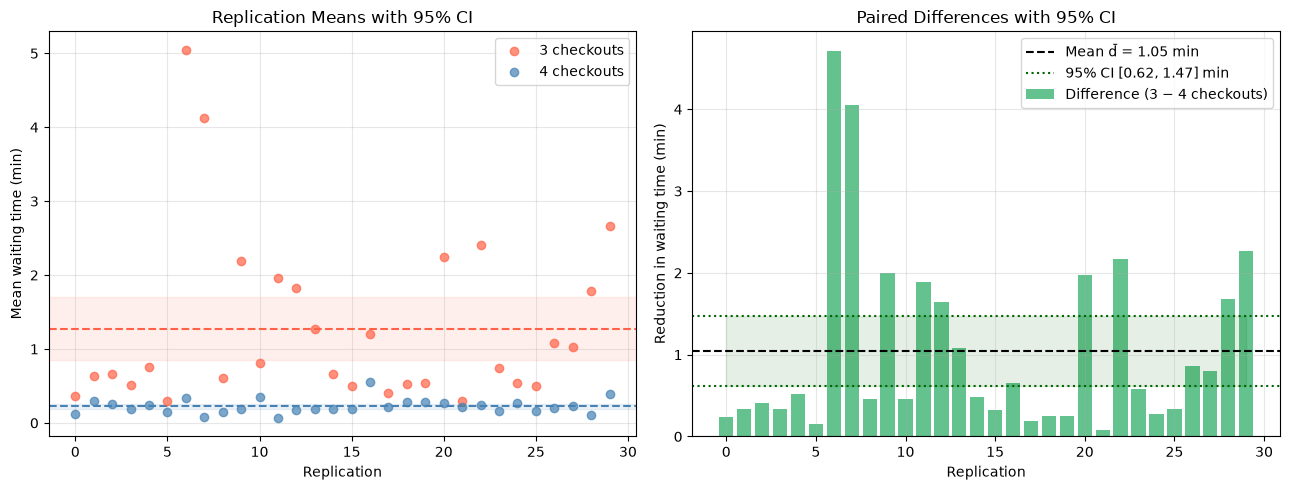

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left panel: Replication means for both configurations ──────────────────
axes[0].scatter(seeds, means_3, color='tomato',    alpha=0.7, label='3 checkouts', zorder=3)
axes[0].scatter(seeds, means_4, color='steelblue', alpha=0.7, label='4 checkouts', zorder=3)

for xbar, lo, hi, color in [(xbar_3, lo_3, hi_3, 'tomato'), (xbar_4, lo_4, hi_4, 'steelblue')]:
    axes[0].axhline(xbar, color=color, linestyle='--', linewidth=1.5)
    axes[0].axhspan(lo, hi, color=color, alpha=0.1)

axes[0].set_xlabel('Replication')
axes[0].set_ylabel('Mean waiting time (min)')
axes[0].set_title('Replication Means with 95% CI')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Right panel: Paired differences with CI ──────────────────────────────
axes[1].bar(seeds, differences, color='mediumseagreen', alpha=0.8, label='Difference (3 − 4 checkouts)')
axes[1].axhline(dbar, color='black',     linestyle='--', linewidth=1.5, label=f'Mean d̄ = {dbar:.2f} min')
axes[1].axhline(lo_d, color='darkgreen', linestyle=':',  linewidth=1.5, label=f'95% CI [{lo_d:.2f}, {hi_d:.2f}] min')
axes[1].axhline(hi_d, color='darkgreen', linestyle=':',  linewidth=1.5)
axes[1].axhline(0,    color='black',     linewidth=0.8, alpha=0.4)
axes[1].fill_between(seeds, lo_d, hi_d, alpha=0.1, color='darkgreen')

axes[1].set_xlabel('Replication')
axes[1].set_ylabel('Reduction in waiting time (min)')
axes[1].set_title('Paired Differences with 95% CI')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Answer to the University Administration's Question

We can now provide a reliable answer to the original question:

> *"By how much would an additional checkout reduce the average waiting time during peak hours?"*

The simulation shows: A fourth checkout reduces the mean waiting time by approximately **1.05 minutes** — from roughly 1.27 min down to roughly 0.22 min. The 95% confidence interval for the reduction lies entirely above 0, confirming that the effect is statistically significant.

## Summary

| Step | Key Takeaway |
|---------|-------------|
| **1 – Deterministic** | With fixed times and ρ < 1, no queue forms |
| **2 – Stochastic** | Randomness creates queues, even at identical utilization |
| **3 – Output Analysis** | A single run is not enough — only many replications + CI yield reliable statements |
| **4 – Comparison** | Common Random Numbers enable a fair, precise configuration comparison |

# Why Do We Need Simulation?

The cafeteria example shows: Even a simple system with known parameters produces **non-intuitive results** under stochasticity.

For the M/M/3 queueing system (3 checkouts, exponentially distributed arrivals and service times), an analytical solution exists — the Erlang-C formula. But this is an exception, not the rule:

- Real systems rarely have exactly exponentially distributed times
- Multiple queues, priorities, breaks, system failures, or dynamic rules quickly make analytical solutions impossible
- Simulation allows arbitrarily realistic models — at the cost of statistical uncertainty in the output

**Garbage-In, Garbage-Out (GIGO):** The quality of the simulation result depends directly on the quality of the model and the input data. A flawed model delivers precisely wrong answers.

→ That is why in this course we learn not only *how* to simulate, but also *how to correctly analyze results*.

# Simulation as a Method for Decision Making: Practical Examples

Simulation is used when classical analytical methods reach their limits. 

<table style="border:none;">
<tr>
  <td style="border:none; vertical-align:top; width:30%; padding-right:25px;">
    <img src="images/stuttgart_hbf.png" style="width:100%; border-radius:4px;"/>
  </td>
  <td style="border:none; vertical-align:top;">

> **How many platforms does the new Stuttgart central station need?**

  </td>
</tr>
</table>

<table style="border:none;">
<tr>
  <td style="border:none; vertical-align:top; width:30%; padding-right:25px;">
    <img src="images/storehouse_3d.png" style="width:100%; border-radius:4px;"/>
  </td>
  <td style="border:none; vertical-align:top;">

> **How many loading docks does a warehouse need with several hundred trucks/day?**

  </td>
</tr>
</table>

<table style="border:none;">
<tr>
  <td style="border:none; vertical-align:top; width:30%; padding-right:25px;">
    <img src="images/ev_charging.jpeg" style="width:100%; border-radius:4px;"/>
  </td>
  <td style="border:none; vertical-align:top;">

> **How many EV charging stations are needed in a city district?**

  </td>
</tr>
</table>

---

# Course Organization

## Instructors

<table style="border:none;">
<tr>
  <td style="border:none; vertical-align:top; padding-right:30px;">

| Role | Person |
|---|---|
| **Lecture** | Prof. Dr. Gunther Gust |
| **Tutorial** | Govind Rao |

  </td>
  <td style="border:none; vertical-align:top; padding-right:15px;">
    <img src="images/prof_gust.jpeg" style="width:130px; border-radius:6px;"/>
  </td>
  <td style="border:none; vertical-align:top;">
    <img src="images/govind_rao.jpg" style="width:130px; border-radius:6px;"/>
  </td>
</tr>
</table>

## About: Prof. Dr. Gunther Gust

<table style="border:none;">
<tr>
  <td style="border:none; vertical-align:top; padding-right:25px;">
    <img src="images/prof_gust.jpeg" style="width:140px; border-radius:6px;"/>
  </td>
  <td style="border:none; vertical-align:top;">

- **Position:** Chair for Enterprise AI, JMU Würzburg (since 2022)
- **PhD:** Summa cum laude (2018), University of Freiburg — *Analytical Information Systems for Decentralized Electricity Networks*
- **Studies:** Business Engineering (B.Sc. & M.Sc. with distinction), Karlsruhe Institute of Technology (KIT)
- **Previous:** Research group leader "Smart Cities and Industries", University of Freiburg; Research stay at Lawrence Berkeley National Laboratory, USA
- **Research interests:** Data-driven decision making, simulation, smart cities, energy systems, mobility

  </td>
</tr>
</table>

## About: Govind Rao

<table style="border:none;">
<tr>
  <td style="border:none; vertical-align:top; padding-right:25px;">
    <img src="images/govind_rao.jpg" style="width:140px; border-radius:6px;"/>
  </td>
  <td style="border:none; vertical-align:top;">

- **Position:** Research Assistant, Chair for Enterprise AI, JMU Würzburg (since 2025)
- **M.Sc.:** Statistics, University of Illinois Urbana-Champaign (UIUC)
- **B.Eng.:** Mechanical Engineering, RCOEM Nagpur, India
- **Previous:** Graduate Research & Teaching Assistant, UIUC; Data Analytics Intern, Delphi Analytics
- **Research interests:** Reinforcement learning, statistical learning, network optimization

  </td>
</tr>
</table>

## Research at the Chair: Autonomous Vehicles & the Taxi Industry

<table style="border:none;">
<tr>
  <td style="border:none; vertical-align:top; width:30%; padding-right:25px;">
    <img src="images/chair_slide12_img2.png" style="width:100%; border-radius:4px;"/>
  </td>
  <td style="border:none; vertical-align:top;">

We use **simulation** to determine the impact of autonomous vehicles on the taxi industry.

- How does the introduction of autonomous vehicles (AVs) through mobility-on-demand platforms (e.g., Uber) affect traditional taxi drivers?
- Simulation of pricing, dispatch, and relocation decisions in a city-wide model

  </td>
</tr>
</table>

## Research at the Chair: Robust Urban Mobility Planning

<table style="border:none;">
<tr>
  <td style="border:none; vertical-align:top; width:30%; padding-right:25px;">
    <img src="images/chair_slide13_img1.jpg" style="width:100%; border-radius:4px;"/>
  </td>
  <td style="border:none; vertical-align:top;">

We use **simulation** to assess the benefits of a reliable route planner vs. a conventional planner (e.g., Google Maps).

- Route planning tools typically ignore travel time **reliability** — we develop a planner that accounts for uncertain travel times
- Simulation of route choice for risk-averse passengers in intermodal urban networks

  </td>
</tr>
</table>

## Research at the Chair: PV System Detection & Electricity Simulation

<table style="border:none;">
<tr>
  <td style="border:none; vertical-align:top; width:30%; padding-right:25px;">
    <img src="images/chair_slide14_img3.jpg" style="width:100%; border-radius:4px;"/>
  </td>
  <td style="border:none; vertical-align:top;">

We detect photovoltaic (PV) systems from aerial images and use **simulation** to estimate their electricity generation.

- Deep learning on aerial images to detect and geolocate solar panels across Germany
- Combination with 3D city models to capture panel orientation
- Deterministic simulation to estimate electricity generation from PV systems

  </td>
</tr>
</table>

## Research at the Chair: Dynamic Electricity Tariffs

<table style="border:none;">
<tr>
  <td style="border:none; vertical-align:top; width:30%; padding-right:25px;">
    <img src="images/chair_slide16_img3.png" style="width:100%; border-radius:4px;"/>
  </td>
  <td style="border:none; vertical-align:top;">

We use **simulation** to estimate the cost impact of dynamic electricity tariffs for households.

- Real-world experiment with Stadtwerke Schweinfurt: How do users adapt to time-varying electricity prices?
- Simulation of cost savings and risk perception under dynamic tariffs
- Recently covered on Bayerischer Rundfunk (BR Frankenschau)

  </td>
</tr>
</table>

## Related Courses

<!-- TODO: Export slide 18 from 1_organization_SS25.pptx as PNG and save as images/chair_related_courses.png -->
<img src="images/chair_related_courses.png" style="width:80%; display:block; margin:16px auto;"/>

## Ways to Work with Us

- **HiWi jobs** (Bachelor's and Master's level)
- **Seminar thesis** — Bachelor, Master, or Project seminar
- **Bachelor's thesis**
- **Master's thesis**
- **Doctorate** — Applications are accepted on an ongoing basis
- Scholarships available

Women are particularly encouraged to apply (see also the Women@WIWI program).

## Course Components

| Component | Details |
|---|---|
| **Lecture** | Theoretical foundations of simulation + Python examples |
| **Tutorial** | Directly after the lecture — Hands-on with Python |
| **Mentimeter Bonus** | Answer Mentimeter quizzes during lectures and exercises · Attend at least 70% of quizzes · Additional attempts can replace worst results · At least 50% correct overall → Bonus: **+0.3 on the exam** |
| **Bonus Project** | In groups · Deadline: 12.07.2026 · Bonus: **+0.3 on the exam** |
| **Mock Exam** | Final week · Including Q&A |
| **Exam** | 60 minutes (pen & paper) · Theory and (some) code questions |

## Bonus Project: Simulation Study for a Small Business in Würzburg

In this bonus project, you will conduct a simulation study for a small business in Würzburg of your choice. 

Examples from past student projects include:
- Jet gas station
- Brückenschoppen
- Ice cream shops
- ...

**Your goal** is to analyze a real-world system, answer a relevant business question, and propose one improvement. (Similar to the Mensa simulation in this lecture)


## Literature

<table style="border:none;">
<tr>
  <td style="border:none; vertical-align:top; padding-right:20px;">
    <img src="images/book_banks.png" style="width:100px; border-radius:4px;"/>
  </td>
  <td style="border:none; vertical-align:top; padding-right:20px;">
    <img src="images/book_waldmann.png" style="width:100px; border-radius:4px;"/>
  </td>
  <td style="border:none; vertical-align:top;">

- **Banks et al. (2014):** *Discrete-Event System Simulation* (5th ed.) — Main textbook of the course
- Law (2015): *Simulation Modeling and Analysis* (5th ed.) — comprehensive, considered the "bible of simulation"
- Ross (2022): *Simulation* (6th ed.) — advanced, very concise and formal
- Waldmann & Helm (2016): *Simulation stochastischer Systeme* — in German, intermediate level

  </td>
</tr>
</table>

## Tools & Communication

- **Python** with the  library + GitHub & Codespaces — you need a free **GitHub account** (sign up at [github.com](https://github.com))
- **WueCampus:** Slides, exercise sheets, organizational information, discussion forum
- **Discord:** Alternative discussion platform
- Please ask questions **exclusively** in the WueCampus forum or on Discord — **no emails**

# Review & Outlook

## What we have seen today

| Step | Key Takeaway |
|---|---|
| **1 – Deterministic** | With fixed times and ρ < 1, no queue forms |
| **2 – Stochastic** | Variability creates queues — even at identical utilization |
| **3 – Output Analysis** | A single run is not reliable — replications + confidence intervals are needed |
| **4 – Comparison** | Common Random Numbers enable a fair and precise comparison of configurations |

## The Simulation Process

The Mensa example has guided us intuitively through a complete simulation study. Here is where each step fits into the general process:

<img src="images/simulation_study_steps.png" style="width:90%; display:block; margin:16px auto;"/>

| What we did in the Mensa example | General step |
|---|---|
| Defined the research question: *How much does a 4th register reduce average waiting time?* | **Problem Formulation** |
| Abstracted the system: registers, students, arrivals, and service processes | **Model Conceptualization** |
| Assumed exponential inter-arrival and service times with known means | **Data Collection & Input Modeling** |
| Implemented the model in Python using SimPy | **Model Translation (Programming)** |
| Used the deterministic model as a sanity check; verified queue behavior against theory | **Verification & Validation** |
| Chose 30 replications and a paired-seed design to reduce variance | **Experimental Design** |
| Computed confidence intervals for 3 and 4 registers; interpreted overlap | **Simulation Runs & Analysis** |
| Derived a concrete, statistically grounded recommendation for the university | **Data & Decision / Implementation** |

# Goal of this Course

Throughout the course, we will revisit each of these steps in detail — building the theoretical foundations and practical skills to apply them to any system.

> **By the end, you will be able to develop a simulation model for any system, analyse its output correctly, and use the results to support real decisions.**